# Model Evaluation: GLM vs XGBoost (Ward 3)

This notebook runs and compares two forecasting pipelines on the same dataset:
- **GLM (Negative Binomial)**
- **XGBoost (Poisson objective)**

It then visualizes model quality with multiple plots and summarizes the results in English.

## Workflow

1. Define shared Hydra overrides for 2021-2025 Ward 3 inputs.
2. Run GLM and XGB training + evaluation.
3. Load saved metrics from `results/<stem>/...json`.
4. Plot metric comparisons and prediction diagnostics.

> Note: `modeling.train` automatically uses `results/best_params_ward3.json` when available, so both GLM and XGB can benefit from tuned feature settings.
5. Grid search for XGB feature tuning and visualize the tuning landscape.

In [1]:
from pathlib import Path
import subprocess
import json
import pickle
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yaml
from omegaconf import OmegaConf

from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.split import make_split
from data.weather_fetch import write_query_config, fetch_and_save



In [2]:
REPO = Path('/data/rpan/course/spring-2026-dc-311')
ENV_NAME = 'dsproj'

# Data exploration

In [3]:
years = [2021, 2022, 2023, 2024, 2025]
rows = []
for y in years:
    for f in sorted((REPO / 'data/311_data').glob(f'ward*_potholes_{y}.parquet')):
        ward = f.name.split('_potholes_')[0]
        n = len(pd.read_parquet(f))
        rows.append({'ward': ward, 'year': y, 'count': n})

ward_count_df = (pd.DataFrame(rows)
                 .groupby('ward', as_index=False)['count']
                 .sum()
                 .sort_values('count', ascending=False)
                 .reset_index(drop=True))

selected_ward_slug = ward_count_df.loc[0, 'ward']
selected_ward_total = int(ward_count_df.loc[0, 'count'])
selected_ward_label = f"Ward {selected_ward_slug.replace('ward','')}"

display(ward_count_df)
print(f'Selected ward for prediction: {selected_ward_label} ({selected_ward_total} requests, 2021-2025 total)')


,ward,count
0,ward3,3192
1,ward5,2652
2,ward4,2315
3,ward2,2085
4,ward6,1955
5,ward8,1803
6,ward7,1724
7,ward1,1419


Selected ward for prediction: Ward 3 (3192 requests, 2021-2025 total)


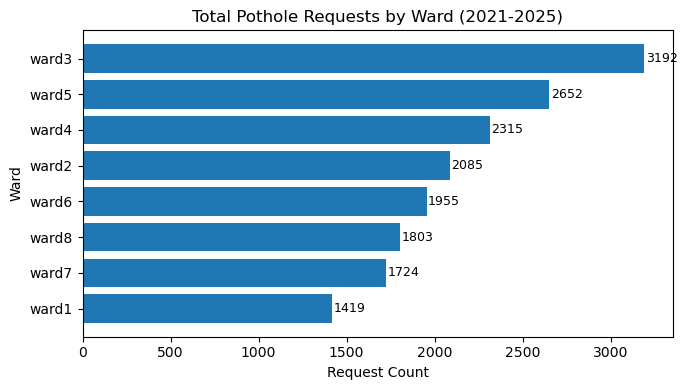

In [26]:
plot_df = ward_count_df.sort_values('count', ascending=True)
plt.figure(figsize=(7, 4))
bars = plt.barh(plot_df['ward'], plot_df['count'])
for b in bars:
    w = int(b.get_width())
    plt.text(w + 8, b.get_y() + b.get_height()/2, f'{w}', va='center', fontsize=9)
plt.title('Total Pothole Requests by Ward (2021-2025)')
plt.xlabel('Request Count')
plt.ylabel('Ward')
plt.tight_layout()
plt.show()


# Extract the weather data for selected ward

Use the ward selected above (max pothole requests).
Currently, centroid coordinates are preconfigured for Ward 3.

In [4]:
if selected_ward_slug != 'ward3':
    raise ValueError('Only ward3 weather centroid is preconfigured in this notebook. Update coordinates for other wards if needed.')

cfg_path = write_query_config(
    ward='Ward 3',
    lat=38.939126092220974,
    lon=-77.077979511738,
    start_date='2020-12-01',
    end_date='2025-12-31',
    configs_dir='data/weather_query_configs',
)
fetch_and_save(cfg_path, cache_dir='data/weather_cache', force=False)


Config written → data/weather_query_configs/weather_ward3_20201201_20251231.json
Cache hit — loaded data/weather_cache/weather_ward3_20201201_20251231.parquet
  Saved at: 2026-03-18T04:58:10.966919+00:00


(                           date  temperature_2m  precipitation  snowfall
 0     2020-11-30 23:00:00-05:00            8.65            0.0       0.0
 1     2020-12-01 00:00:00-05:00            8.10            0.0       0.0
 2     2020-12-01 01:00:00-05:00            7.35            0.0       0.0
 3     2020-12-01 02:00:00-05:00            7.45            0.0       0.0
 4     2020-12-01 03:00:00-05:00            7.50            0.0       0.0
 ...                         ...             ...            ...       ...
 44563 2025-12-31 18:00:00-05:00            0.55            0.0       0.0
 44564 2025-12-31 19:00:00-05:00            0.10            0.0       0.0
 44565 2025-12-31 20:00:00-05:00            0.35            0.0       0.0
 44566 2025-12-31 21:00:00-05:00            0.75            0.0       0.0
 44567 2025-12-31 22:00:00-05:00            1.20            0.0       0.0
 
 [44568 rows x 4 columns],
 {'label': 'weather_ward3_20201201_20251231',
  'ward': 'Ward 3',
  'description': 

# Loading selected ward data

In [5]:
RAW311 = '[' + ','.join([f'data/311_data/{selected_ward_slug}_potholes_{y}.parquet' for y in [2021, 2022, 2023, 2024, 2025]]) + ']'
WEATHER = 'data/weather_cache/weather_ward3_20201201_20251231.parquet'
COMMON = [
    f'ward={selected_ward_slug}',
    f'ward.raw_311={RAW311}',
    f'ward.weather_cache={WEATHER}',
    'debug.verbose=false',
]

print('Selected ward:', selected_ward_label)
print('RAW311:', RAW311)
print('Weather file exists:', (REPO / WEATHER).exists())


Selected ward: Ward 3
RAW311: [data/311_data/ward3_potholes_2021.parquet,data/311_data/ward3_potholes_2022.parquet,data/311_data/ward3_potholes_2023.parquet,data/311_data/ward3_potholes_2024.parquet,data/311_data/ward3_potholes_2025.parquet]
Weather file exists: True


data inspect command:

- python run.py inspect-master "${COMMON[@]}"
- python run.py inspect-features "${COMMON[@]}"
- python run.py inspect-split "${COMMON[@]}"


In [6]:
def run_cmd(cmd):
    print('$', ' '.join(cmd))
    env = dict(**__import__('os').environ)
    env['PYTHONBREAKPOINT'] = '0'
    proc = subprocess.run(cmd, cwd=REPO, text=True, capture_output=True, env=env)
    if proc.stdout:
        print(proc.stdout)
    if proc.returncode != 0:
        print(proc.stderr)
        raise RuntimeError(f'Command failed: {proc.returncode}')
    return proc.stdout

# Get the latest model file
def latest_stem(prefix):
    dirs = [p for p in (REPO / 'results').glob(f'{prefix}*') if p.is_dir()]
    if not dirs:
        raise FileNotFoundError(f'No run directory found for prefix: {prefix}')
    return sorted(dirs, key=lambda p: p.stat().st_mtime, reverse=True)[0].name

def load_metrics(stem):
    run_dir = REPO / 'results' / stem
    train = json.loads((run_dir / 'train_metrics.json').read_text())
    test = json.loads((run_dir / 'test_metrics.json').read_text())
    return train, test


## XGBoost Grid Search (Feature Tuning)

This section runs the existing Hydra grid search pipeline:
- `python -m modeling.search.grid +search=grid ...`

It tunes feature parameters (`d`, rolling windows/lags, `k_AR`) and stores results in `results/grid_ward3.csv`.
Then we visualize the tuning landscape to understand which parameter settings are robust.

In [7]:
# Grid search can be expensive (~40k+ combinations with current config).
# Switch to True when you want to run it from this notebook.
RUN_GRID_SEARCH = True

if RUN_GRID_SEARCH:
    run_cmd(['conda', 'run', '-n', ENV_NAME, 'python', '-m', 'modeling.search.grid', '+search=grid', *COMMON])
else:
    print('Skip running grid search. Using existing results/grid_ward3.csv if available.')


$ conda run -n dsproj python -m modeling.search.grid +search=grid ward=ward3 ward.raw_311=[data/311_data/ward3_potholes_2021.parquet,data/311_data/ward3_potholes_2022.parquet,data/311_data/ward3_potholes_2023.parquet,data/311_data/ward3_potholes_2024.parquet,data/311_data/ward3_potholes_2025.parquet] ward.weather_cache=data/weather_cache/weather_ward3_20201201_20251231.parquet debug.verbose=false


KeyboardInterrupt: 

In [19]:
param_cols = ['d', 'd_p', 'l_p', 'd_s', 'l_s', 'd_f', 'l_f', 'k_AR']
grid_path = REPO / 'results' / 'grid_ward3.csv'
if not grid_path.exists():
    raise FileNotFoundError(f'Grid result not found: {grid_path}. Set RUN_GRID_SEARCH=True first.')

grid_df = pd.read_csv(grid_path)
print(f'Loaded grid results: {grid_df.shape[0]:,} rows, {grid_df.shape[1]} columns')
display(grid_df.head())

best_grid_row = grid_df.iloc[0]
best_grid_params = {k: int(best_grid_row[k]) for k in param_cols}
print('Best grid params:')
print(json.dumps(best_grid_params, indent=2))
print(f"Best grid val_mae: {best_grid_row['val_mae']:.4f}")

# Optional: make training use grid-best params by writing best_params_ward3.json
USE_GRID_BEST_FOR_TRAINING = True
if USE_GRID_BEST_FOR_TRAINING:
    payload = dict(best_grid_params)
    payload['val_mae'] = float(best_grid_row['val_mae'])
    out = REPO / 'results' / 'best_params_ward3.json'
    out.write_text(json.dumps(payload, indent=2))
    print(f'Wrote {out} with grid-best params')


Loaded grid results: 41,472 rows, 10 columns


,d,d_p,l_p,d_s,l_s,d_f,l_f,k_AR,val_mae,val_poisson_dev
0,1,14,10,7,0,7,0,10,1.263745,1.774605
1,1,21,3,7,0,7,0,10,1.263903,1.771689
2,1,7,5,7,0,7,0,10,1.265003,1.778335
3,1,7,10,7,0,7,0,10,1.265003,1.780839
4,1,21,5,7,0,7,0,10,1.265065,1.777909


Best grid params:
{
  "d": 1,
  "d_p": 14,
  "l_p": 10,
  "d_s": 7,
  "l_s": 0,
  "d_f": 7,
  "l_f": 0,
  "k_AR": 10
}
Best grid val_mae: 1.2637
Wrote /data/rpan/course/spring-2026-dc-311/results/best_params_ward3.json with grid-best params


### Grid Tuning Visualization 

Keep only the most informative views:
- **Ranked val_mae curve**: shows how quickly performance degrades after the best configurations.
- **Parameter sensitivity (mean/min)**: shows which feature parameters matter most.

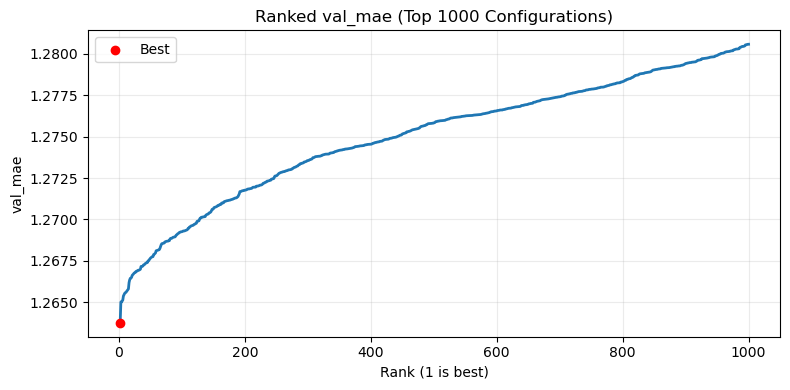

In [21]:
# 1) Ranked performance curve (best -> worse)
rank_df = grid_df.reset_index(drop=True).copy()
rank_df['rank'] = rank_df.index + 1

top_n = min(1000, len(rank_df))
view = rank_df.loc[:top_n-1]

plt.figure(figsize=(8, 4))
plt.plot(view['rank'], view['val_mae'], linewidth=2)
plt.scatter([1], [view['val_mae'].iloc[0]], color='red', zorder=3, label='Best')
plt.title(f'Ranked val_mae (Top {top_n} Configurations)')
plt.xlabel('Rank (1 is best)')
plt.ylabel('val_mae')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

#display(rank_df.head(10)[['rank', *param_cols, 'val_mae', 'val_poisson_dev']])


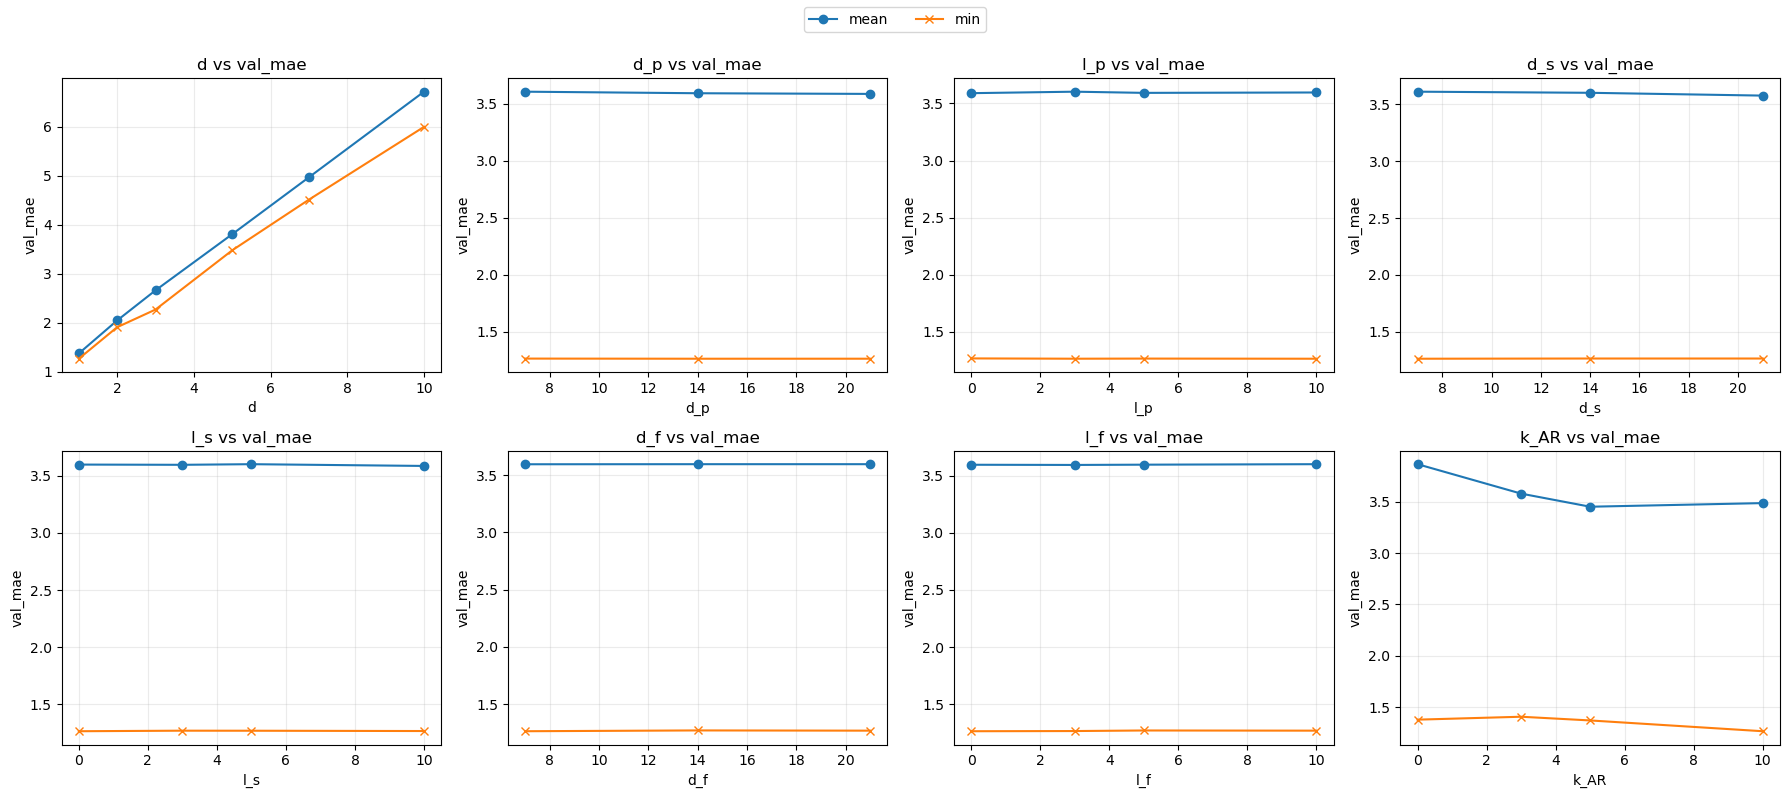

In [22]:
# 2) Parameter sensitivity: mean/min val_mae by each parameter value
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, p in zip(axes.flat, param_cols):
    agg = grid_df.groupby(p)['val_mae'].agg(['mean', 'min']).sort_index()
    ax.plot(agg.index, agg['mean'], marker='o', label='mean')
    ax.plot(agg.index, agg['min'], marker='x', label='min')
    ax.set_title(f'{p} vs val_mae')
    ax.set_xlabel(p)
    ax.set_ylabel('val_mae')
    ax.grid(alpha=0.25)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [23]:
# Set to False if you want to reuse existing recent runs only.
RUN_TRAINING = True

if RUN_TRAINING:
    # GLM
    run_cmd(['conda', 'run', '-n', ENV_NAME, 'python', '-m', 'modeling.train', 'model=glm', *COMMON],)
    stem_glm = latest_stem('ward3_negbin_glm_')
    run_cmd(['conda', 'run', '-n', ENV_NAME, 'python', '-m', 'modeling.evaluate', f'load_model={stem_glm}'])

    # XGB
    run_cmd(['conda', 'run', '-n', ENV_NAME, 'python', '-m', 'modeling.train', 'model=xgb', *COMMON],)
    stem_xgb = latest_stem('ward3_xgb_')
    run_cmd(['conda', 'run', '-n', ENV_NAME, 'python', '-m', 'modeling.evaluate', f'load_model={stem_xgb}'])
else:
    stem_glm = latest_stem('ward3_negbin_glm_')
    stem_xgb = latest_stem('ward3_xgb_')

print('GLM stem:', stem_glm)
print('XGB stem:', stem_xgb)


$ conda run -n dsproj python -m modeling.train model=glm ward=ward3 ward.raw_311=[data/311_data/ward3_potholes_2021.parquet,data/311_data/ward3_potholes_2022.parquet,data/311_data/ward3_potholes_2023.parquet,data/311_data/ward3_potholes_2024.parquet,data/311_data/ward3_potholes_2025.parquet] ward.weather_cache=data/weather_cache/weather_ward3_20201201_20251231.parquet debug.verbose=false
Using best params from results/best_params_ward3.json
CV metrics: {'cv_mae': 1.35847754265187, 'cv_rmse': 2.150408507108355, 'cv_poisson_deviance': 1.8835199312648911}
run_id      → 20260318_2fa9c65b
wx_range    → 20201130_20251231
Model saved → results/ward3_negbin_glm_20201130_20251231_20260318_2fa9c65b/model.pkl
Run config  → results/ward3_negbin_glm_20201130_20251231_20260318_2fa9c65b/run.yaml
Metrics     → results/ward3_negbin_glm_20201130_20251231_20260318_2fa9c65b/train_metrics.json
Final val MAE: 1.2692

$ conda run -n dsproj python -m modeling.evaluate load_model=ward3_negbin_glm_20201130_2025

In [24]:
train_glm, test_glm = load_metrics(stem_glm)
train_xgb, test_xgb = load_metrics(stem_xgb)

summary_df = pd.DataFrame([
    {
        'model': 'GLM',
        'stem': stem_glm,
        'cv_mae': train_glm['cv_mae'],
        'val_mae': train_glm['val_mae'],
        'test_mae': test_glm['test_mae'],
        'test_rmse': test_glm['test_rmse'],
        'test_poisson_deviance': test_glm['test_poisson_deviance'],
    },
    {
        'model': 'XGB',
        'stem': stem_xgb,
        'cv_mae': train_xgb['cv_mae'],
        'val_mae': train_xgb['val_mae'],
        'test_mae': test_xgb['test_mae'],
        'test_rmse': test_xgb['test_rmse'],
        'test_poisson_deviance': test_xgb['test_poisson_deviance'],
    },
]).set_index('model')

summary_df


,stem,cv_mae,val_mae,test_mae,test_rmse,test_poisson_deviance
model,,,,,,
GLM,ward3_negbin_glm_20201130_20251231_20260318_2f...,1.358478,1.269246,1.382671,2.237815,1.904551
XGB,ward3_xgb_20201130_20251231_20260318_f1b10586,1.328596,0.618435,1.285893,1.833975,1.760023


## Metric Comparison Plots

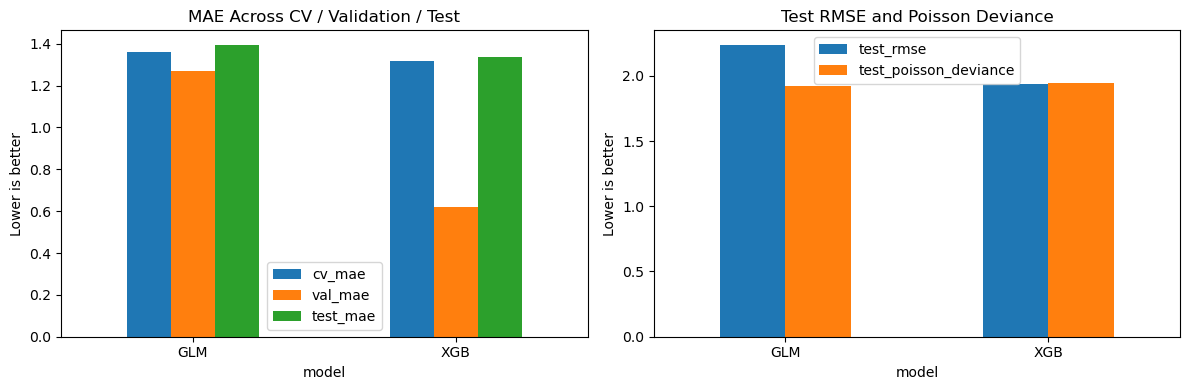

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
summary_df[['cv_mae', 'val_mae', 'test_mae']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('MAE Across CV / Validation / Test')
axes[0].set_ylabel('Lower is better')

summary_df[['test_rmse', 'test_poisson_deviance']].plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Test RMSE and Poisson Deviance')
axes[1].set_ylabel('Lower is better')

plt.tight_layout()
plt.show()


## Prediction-Level Diagnostics

In [ ]:
def reconstruct_test_predictions(stem):
    run_dir = REPO / 'results' / stem
    run_data = yaml.safe_load((run_dir / 'run.yaml').read_text())
    run_cfg = OmegaConf.create(run_data)

    with open(run_dir / 'model.pkl', 'rb') as f:
        saved = pickle.load(f)

    model = saved['model']
    feature_cols = saved['feature_cols']
    feat_params = SimpleNamespace(**saved['feat_params'])

    pothole_df, weather_df = build_daily(run_cfg)
    feat_df = assemble_features(pothole_df, weather_df, feat_params)
    feat_df = make_split(feat_df, run_cfg.split)

    test_df = feat_df[feat_df['split'] == 'test'].copy()
    test_df['date'] = pd.to_datetime(test_df['date'])
    X_test = test_df[feature_cols]
    y_test = test_df['Y'].values
    preds = model.predict(X_test)

    out = pd.DataFrame({
        'date': test_df['date'].values,
        'actual': y_test,
        'pred': preds,
    }).sort_values('date').reset_index(drop=True)
    out['residual'] = out['actual'] - out['pred']
    return out

pred_glm = reconstruct_test_predictions(stem_glm)
pred_xgb = reconstruct_test_predictions(stem_xgb)

pred_glm.head(), pred_xgb.head()


(        date  actual      pred  residual
 0 2021-01-15     0.0  1.038560 -1.038560
 1 2021-01-25     1.0  1.737695 -0.737695
 2 2021-02-12     1.0  1.268146 -0.268146
 3 2021-02-14     3.0  3.054499 -0.054499
 4 2021-02-23     7.0  2.642980  4.357020,
         date  actual      pred  residual
 0 2021-01-15     0.0  0.572730 -0.572730
 1 2021-01-25     1.0  2.055834 -1.055834
 2 2021-02-12     1.0  0.945120  0.054880
 3 2021-02-14     3.0  1.945416  1.054584
 4 2021-02-23     7.0  3.496829  3.503171)

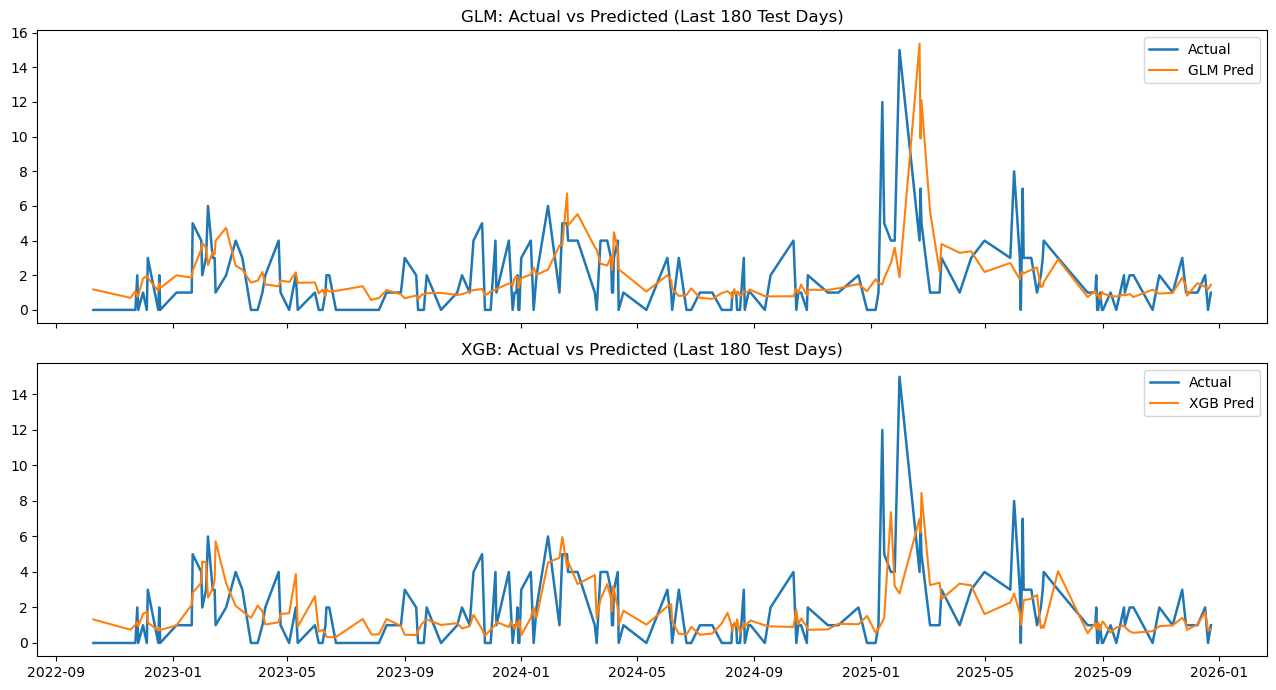

In [7]:
# Time-series comparison (last 180 test days)
n = 180
g = pred_glm.tail(n)
x = pred_xgb.tail(n)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(g['date'], g['actual'], label='Actual', linewidth=1.8)
axes[0].plot(g['date'], g['pred'], label='GLM Pred', linewidth=1.5)
axes[0].set_title('GLM: Actual vs Predicted (Last 180 Test Days)')
axes[0].legend()

axes[1].plot(x['date'], x['actual'], label='Actual', linewidth=1.8)
axes[1].plot(x['date'], x['pred'], label='XGB Pred', linewidth=1.5)
axes[1].set_title('XGB: Actual vs Predicted (Last 180 Test Days)')
axes[1].legend()

plt.tight_layout()
plt.show()


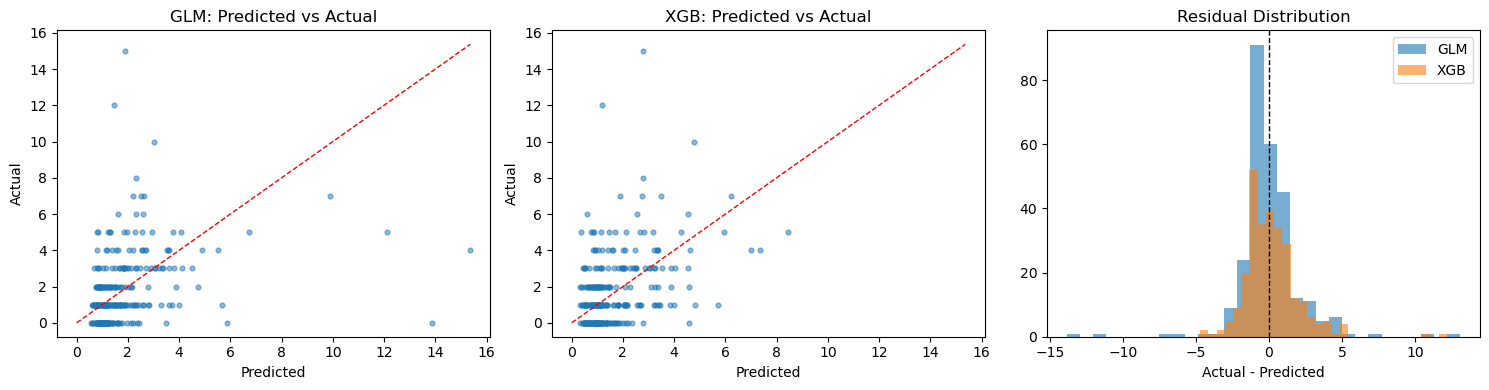

In [8]:
# Scatter + residual distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lo = min(pred_glm[['actual', 'pred']].min().min(), pred_xgb[['actual', 'pred']].min().min())
hi = max(pred_glm[['actual', 'pred']].max().max(), pred_xgb[['actual', 'pred']].max().max())

axes[0].scatter(pred_glm['pred'], pred_glm['actual'], alpha=0.5, s=12)
axes[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
axes[0].set_title('GLM: Predicted vs Actual')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

axes[1].scatter(pred_xgb['pred'], pred_xgb['actual'], alpha=0.5, s=12)
axes[1].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
axes[1].set_title('XGB: Predicted vs Actual')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

axes[2].hist(pred_glm['residual'], bins=30, alpha=0.6, label='GLM')
axes[2].hist(pred_xgb['residual'], bins=30, alpha=0.6, label='XGB')
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Actual - Predicted')
axes[2].legend()

plt.tight_layout()
plt.show()


In [9]:
improve_test_mae = (summary_df.loc['GLM', 'test_mae'] - summary_df.loc['XGB', 'test_mae']) / summary_df.loc['GLM', 'test_mae'] * 100
improve_test_rmse = (summary_df.loc['GLM', 'test_rmse'] - summary_df.loc['XGB', 'test_rmse']) / summary_df.loc['GLM', 'test_rmse'] * 100

print(f"Test MAE improvement (XGB vs GLM): {improve_test_mae:.2f}%")
print(f"Test RMSE improvement (XGB vs GLM): {improve_test_rmse:.2f}%")
summary_df


Test MAE improvement (XGB vs GLM): 3.99%
Test RMSE improvement (XGB vs GLM): 13.42%


,stem,cv_mae,val_mae,test_mae,test_rmse,test_poisson_deviance
model,,,,,,
GLM,ward3_negbin_glm_20201130_20251231_20260318_47...,1.360693,1.267653,1.394619,2.236328,1.923321
XGB,ward3_xgb_20201130_20251231_20260318_9c302e4f,1.318146,0.618298,1.338940,1.936161,1.945566
